# Tridimensional FAEMD (FAEMD3D)

**FAEMD3D** extends Fast and Adaptive EMD to volumetric data:

- extrema from a **26-neighbour** comparison;
- adaptive window via **3-D Delaunay** nearest edges;
- **separable** order-statistics envelopes along $x,y,z$.

**Reference:** Thirumalaisamy & Ansell, IEEE SPL 2018; FA-MVEMD MATLAB toolbox.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import FAEMD3D

print(FAEMD3D())

Tridimensional Fast and Adaptive Empirical Mode Decomposition (FAEMD3D)


## 1. Synthetic volume

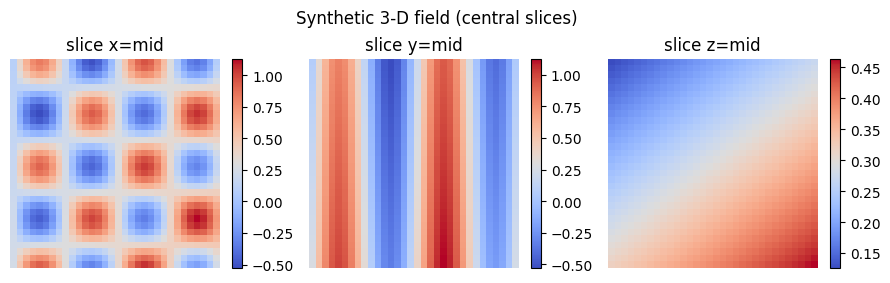

In [2]:
n = 32
zz, yy, xx = np.mgrid[0:n, 0:n, 0:n]
xx, yy, zz = xx / n, yy / n, zz / n

trend = 0.25 * xx + 0.15 * yy + 0.2 * zz
osc = 0.7 * np.sin(2 * np.pi * 2 * xx) * np.cos(2 * np.pi * 2 * yy)
vol = trend + osc

mid = n // 2
fig, axes = plt.subplots(1, 3, figsize=(9, 2.8))
for ax, sl, title in zip(
    axes,
    [vol[mid], vol[:, mid], vol[:, :, mid]],
    ["slice x=mid", "slice y=mid", "slice z=mid"],
):
    im = ax.imshow(sl, cmap="coolwarm")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Synthetic 3-D field (central slices)")
plt.tight_layout()
plt.show()

## 2. Decomposition

TIMFs shape: (3, 32, 32, 32)
max |recon error|: 0.0


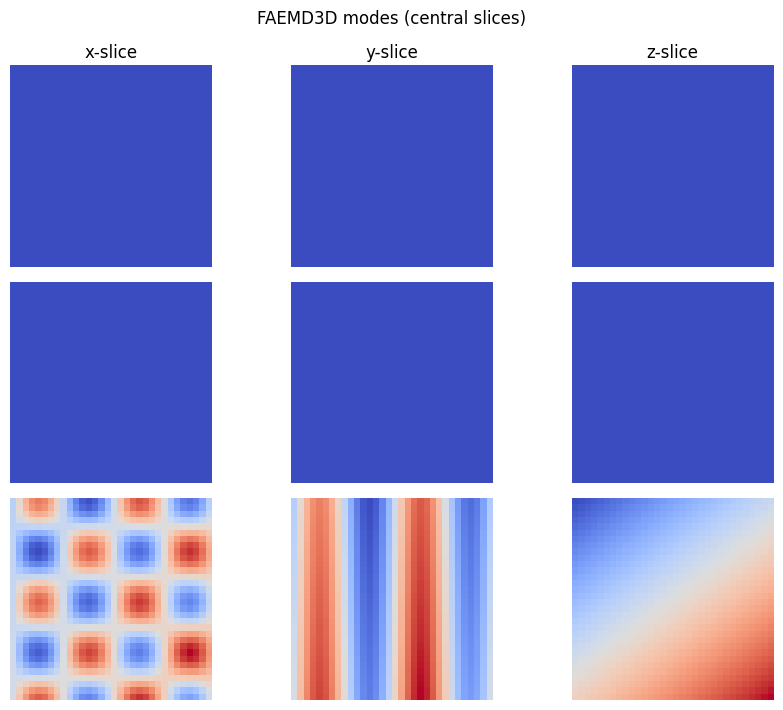

In [3]:
timfs = FAEMD3D(max_imfs=3, tol=0.08, window_type=5).fit_transform(vol)
print("TIMFs shape:", timfs.shape)
print("max |recon error|:", np.max(np.abs(timfs.sum(0) - vol)))

K = timfs.shape[0]
fig, axes = plt.subplots(K, 3, figsize=(9, 2.4 * K))
for k in range(K):
    for j, sl in enumerate([timfs[k, mid], timfs[k, :, mid], timfs[k, :, :, mid]]):
        axes[k, j].imshow(sl, cmap="coolwarm")
        axes[k, j].axis("off")
        if k == 0:
            axes[k, j].set_title(["x-slice", "y-slice", "z-slice"][j])
    axes[k, 0].set_ylabel("residue" if k == K - 1 else f"TIMF {k}")
plt.suptitle("FAEMD3D modes (central slices)")
plt.tight_layout()
plt.show()

## 3. API

```python
from pysdkit import FAEMD3D

fa = FAEMD3D(max_imfs=3, tol=0.05, window_type=5)
TIMFs = fa.fit_transform(volume)           # (K, X, Y, Z)
TIMFs = fa.fit_transform(channels)         # (N, X, Y, Z) → (K, N, X, Y, Z)
```

Tips: keep volumes modest for interactive work — separable OSF is much faster
than full 3-D spline BEMD, but still $O(K \cdot N_{\mathrm{vox}} \cdot w)$.